<a href="https://colab.research.google.com/github/Shrawanpandit/Machine_Learning_Lab-Works/blob/main/MachineLearning_Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part A: Logistic Regression

### Task 1: Load the Dataset

In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

### Task 2: Explore the Dataset

In [2]:
# 1. Display the shape of X and y
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# 2. Print the first five rows of X
print("\nFirst five rows of X:")
print(X[:5])

# 3. Identify number of samples, number of features, and number of classes
num_samples = X.shape[0]
num_features = X.shape[1]
num_classes = len(set(y))

print(f"\nNumber of samples: {num_samples}")
print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")

Shape of X: (569, 30)
Shape of y: (569,)

First five rows of X:
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1

### Task 3: Split the Dataset

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


### Task 4: Standardize Features

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of scaled X_train: {X_train_scaled.shape}")
print(f"Shape of scaled X_test: {X_test_scaled.shape}")

Shape of scaled X_train: (455, 30)
Shape of scaled X_test: (114, 30)


### Task 5: Train Logistic Regression Model

In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Task 6: Make Predictions

In [6]:
# Predict class labels for the test set
y_pred = model.predict(X_test_scaled)

print("Predictions made successfully.")
# Display first 5 predictions
print("\nFirst 5 predictions:", y_pred[:5])
print("First 5 actual labels:", y_test[:5])

Predictions made successfully.

First 5 predictions: [1 0 0 1 1]
First 5 actual labels: [1 0 0 1 1]


### Task 7: Evaluate the Model

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# 2. Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# 3. Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

# 4. F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

# 5. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1-score: 0.9790

Confusion Matrix:
[[41  2]
 [ 1 70]]


### Task 8: Interpret Coefficients

In [9]:
import pandas as pd

# Display the coefficients of the trained model
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# To make interpretation easier, let's associate coefficients with feature names
feature_names = data.feature_names
coefficients = model.coef_[0]

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
print("\nSorted Coefficients:")
print(coef_df)

Coefficients: [[-0.43190368 -0.38732553 -0.39343248 -0.46521006 -0.07166728  0.54016395
  -0.8014581  -1.11980408  0.23611852  0.07592093 -1.26817815  0.18887738
  -0.61058302 -0.9071857  -0.31330675  0.68249145  0.17527452 -0.3112999
   0.50042502  0.61622993 -0.87984024 -1.35060559 -0.58945273 -0.84184594
  -0.54416967  0.01611019 -0.94305313 -0.77821726 -1.20820031 -0.15741387]]
Intercept: [0.44558453]

Sorted Coefficients:
                    Feature  Coefficient
15        compactness error     0.682491
19  fractal dimension error     0.616230
5          mean compactness     0.540164
18           symmetry error     0.500425
8             mean symmetry     0.236119
11            texture error     0.188877
16          concavity error     0.175275
9    mean fractal dimension     0.075921
25        worst compactness     0.016110
4           mean smoothness    -0.071667
29  worst fractal dimension    -0.157414
17     concave points error    -0.311300
14         smoothness error    -0.31

#### Questions:
1. Which feature has the largest positive coefficient?
2. Which feature has the largest negative coefficient?
3. What does the sign of a coefficient indicate?

## Part B: Support Vector Classification (SVC)

### Task 1: Load the Dataset

In [10]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print("Iris dataset loaded successfully.")

Iris dataset loaded successfully.


### Task 2: Explore the Iris Dataset

In [11]:
# 1. Display the shape of X_iris and y_iris
print(f"Shape of X_iris: {X_iris.shape}")
print(f"Shape of y_iris: {y_iris.shape}")

# 2. Print the first five rows of X_iris
print("\nFirst five rows of X_iris:")
print(X_iris[:5])

# 3. Identify number of samples, number of features, and number of classes
num_samples_iris = X_iris.shape[0]
num_features_iris = X_iris.shape[1]
num_classes_iris = len(set(y_iris))

print(f"\nNumber of samples in Iris dataset: {num_samples_iris}")
print(f"Number of features in Iris dataset: {num_features_iris}")
print(f"Number of classes in Iris dataset: {num_classes_iris}")

Shape of X_iris: (150, 4)
Shape of y_iris: (150,)

First five rows of X_iris:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Number of samples in Iris dataset: 150
Number of features in Iris dataset: 4
Number of classes in Iris dataset: 3


### Task 3: Split the Iris Dataset

In [12]:
from sklearn.model_selection import train_test_split

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

print(f"Shape of X_iris_train: {X_iris_train.shape}")
print(f"Shape of X_iris_test: {X_iris_test.shape}")
print(f"Shape of y_iris_train: {y_iris_train.shape}")
print(f"Shape of y_iris_test: {y_iris_test.shape}")

Shape of X_iris_train: (120, 4)
Shape of X_iris_test: (30, 4)
Shape of y_iris_train: (120,)
Shape of y_iris_test: (30,)


### Task 4: Standardize Features for Iris Dataset

In [13]:
from sklearn.preprocessing import StandardScaler

scaler_iris = StandardScaler()
X_iris_train_scaled = scaler_iris.fit_transform(X_iris_train)
X_iris_test_scaled = scaler_iris.transform(X_iris_test)

print(f"Shape of scaled X_iris_train: {X_iris_train_scaled.shape}")
print(f"Shape of scaled X_iris_test: {X_iris_test_scaled.shape}")

Shape of scaled X_iris_train: (120, 4)
Shape of scaled X_iris_test: (30, 4)


### Task 5: Train SVC Models

In [14]:
from sklearn.svm import SVC

# Initialize and train SVC with Linear Kernel
svc_linear = SVC(kernel='linear', random_state=42)
svc_linear.fit(X_iris_train_scaled, y_iris_train)

# Initialize and train SVC with RBF Kernel
svc_rbf = SVC(kernel='rbf', random_state=42)
svc_rbf.fit(X_iris_train_scaled, y_iris_train)

print("SVC models (Linear and RBF kernels) trained successfully.")

SVC models (Linear and RBF kernels) trained successfully.


### Task 6: Make Predictions with SVC Models

In [15]:
# Predict class labels for the test set using the Linear SVC model
y_pred_svc_linear = svc_linear.predict(X_iris_test_scaled)

# Predict class labels for the test set using the RBF SVC model
y_pred_svc_rbf = svc_rbf.predict(X_iris_test_scaled)

print("Predictions made successfully with both Linear and RBF SVC models.")

# Display first 5 predictions for Linear SVC
print("\nFirst 5 predictions (Linear SVC):", y_pred_svc_linear[:5])
print("First 5 actual labels (Iris):", y_iris_test[:5])

# Display first 5 predictions for RBF SVC
print("\nFirst 5 predictions (RBF SVC):", y_pred_svc_rbf[:5])

Predictions made successfully with both Linear and RBF SVC models.

First 5 predictions (Linear SVC): [1 0 2 1 1]
First 5 actual labels (Iris): [1 0 2 1 1]

First 5 predictions (RBF SVC): [1 0 2 1 1]


### Task 7: Evaluate SVC Models


--- Linear SVC Model Evaluation ---
Accuracy (Linear SVC): 0.9667
Precision (Linear SVC): 0.9694
Recall (Linear SVC): 0.9667
F1-score (Linear SVC): 0.9664

Confusion Matrix (Linear SVC):
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


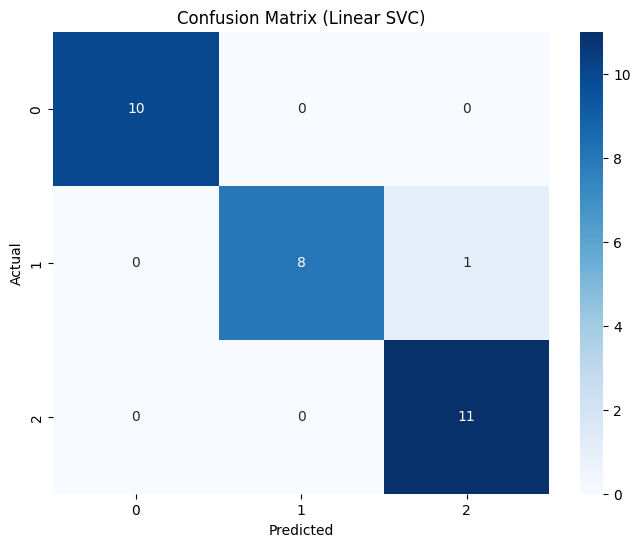


--- RBF SVC Model Evaluation ---
Accuracy (RBF SVC): 1.0000
Precision (RBF SVC): 1.0000
Recall (RBF SVC): 1.0000
F1-score (RBF SVC): 1.0000

Confusion Matrix (RBF SVC):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


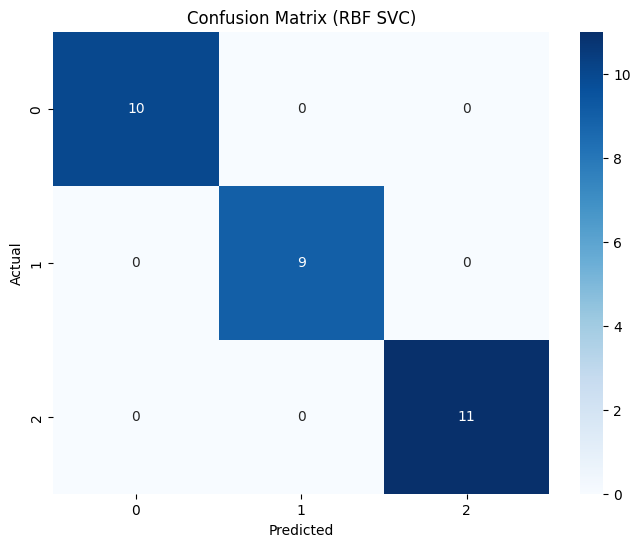

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Evaluate Linear SVC Model ---
print("\n--- Linear SVC Model Evaluation ---")
accuracy_linear = accuracy_score(y_iris_test, y_pred_svc_linear)
precision_linear = precision_score(y_iris_test, y_pred_svc_linear, average='weighted')
recall_linear = recall_score(y_iris_test, y_pred_svc_linear, average='weighted')
f1_linear = f1_score(y_iris_test, y_pred_svc_linear, average='weighted')

print(f"Accuracy (Linear SVC): {accuracy_linear:.4f}")
print(f"Precision (Linear SVC): {precision_linear:.4f}")
print(f"Recall (Linear SVC): {recall_linear:.4f}")
print(f"F1-score (Linear SVC): {f1_linear:.4f}")

conf_matrix_linear = confusion_matrix(y_iris_test, y_pred_svc_linear)
print("\nConfusion Matrix (Linear SVC):")
print(conf_matrix_linear)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_linear, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Linear SVC)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Evaluate RBF SVC Model ---
print("\n--- RBF SVC Model Evaluation ---")
accuracy_rbf = accuracy_score(y_iris_test, y_pred_svc_rbf)
precision_rbf = precision_score(y_iris_test, y_pred_svc_rbf, average='weighted')
recall_rbf = recall_score(y_iris_test, y_pred_svc_rbf, average='weighted')
f1_rbf = f1_score(y_iris_test, y_pred_svc_rbf, average='weighted')

print(f"Accuracy (RBF SVC): {accuracy_rbf:.4f}")
print(f"Precision (RBF SVC): {precision_rbf:.4f}")
print(f"Recall (RBF SVC): {recall_rbf:.4f}")
print(f"F1-score (RBF SVC): {f1_rbf:.4f}")

conf_matrix_rbf = confusion_matrix(y_iris_test, y_pred_svc_rbf)
print("\nConfusion Matrix (RBF SVC):")
print(conf_matrix_rbf)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rbf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (RBF SVC)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Task 8: Compare SVC Model Performance

**Comparison:**

From the evaluation metrics, the **RBF SVC model (Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000)** significantly outperformed the **Linear SVC model (Accuracy: 0.9667, Precision: 0.9694, Recall: 0.9667, F1-score: 0.9664)** on this specific Iris dataset test set.

**Which kernel performed better and why?**

The **RBF kernel performed better** in this case, achieving perfect classification on the test set. This suggests that the Iris dataset, while linearly separable to a high degree, likely has some non-linear patterns or decision boundaries that the RBF kernel was able to capture more effectively than the linear kernel. The RBF kernel, by mapping data into a higher-dimensional space, can create more complex, non-linear decision boundaries, which appears to be advantageous for this dataset. The linear kernel, constrained to a linear decision boundary, was not able to perfectly separate all classes, leading to one misclassification in the confusion matrix.

## Part C: Support Vector Regression (SVR)

### Task 1: Load Dataset

In [17]:
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target

# 1. Number of observations
num_observations_housing = X_housing.shape[0]
print(f"Number of observations: {num_observations_housing}")

# 2. Number of features
num_features_housing = X_housing.shape[1]
print(f"Number of features: {num_features_housing}")

# 3. Description of the target variable
print("\nDescription of the target variable (median house value):\n")
print(housing.DESCR)

Number of observations: 20640
Number of features: 8

Description of the target variable (median house value):

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundred

### Task 2: Split Dataset

In [18]:
from sklearn.model_selection import train_test_split

X_housing_train, X_housing_test, y_housing_train, y_housing_test = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)

print(f"Shape of X_housing_train: {X_housing_train.shape}")
print(f"Shape of X_housing_test: {X_housing_test.shape}")
print(f"Shape of y_housing_train: {y_housing_train.shape}")
print(f"Shape of y_housing_test: {y_housing_test.shape}")

Shape of X_housing_train: (16512, 8)
Shape of X_housing_test: (4128, 8)
Shape of y_housing_train: (16512,)
Shape of y_housing_test: (4128,)


### Task 3: Standardize Features

In [19]:
from sklearn.preprocessing import StandardScaler

scaler_housing = StandardScaler()
X_housing_train_scaled = scaler_housing.fit_transform(X_housing_train)
X_housing_test_scaled = scaler_housing.transform(X_housing_test)

print(f"Shape of scaled X_housing_train: {X_housing_train_scaled.shape}")
print(f"Shape of scaled X_housing_test: {X_housing_test_scaled.shape}")

Shape of scaled X_housing_train: (16512, 8)
Shape of scaled X_housing_test: (4128, 8)


### Task 4: Train Linear SVR Model

In [20]:
from sklearn.svm import LinearSVR

# Initialize and train the Linear SVR model
linear_svr = LinearSVR(random_state=42, dual=True)
linear_svr.fit(X_housing_train_scaled, y_housing_train)

print("Linear SVR model trained successfully.")

Linear SVR model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### Task 5: Make Predictions with Linear SVR

In [21]:
# Predict on the scaled test data
y_housing_pred_linear_svr = linear_svr.predict(X_housing_test_scaled)

print("Predictions with Linear SVR made successfully.")
# Display first 5 predictions
print("\nFirst 5 predictions (Linear SVR):", y_housing_pred_linear_svr[:5])
print("First 5 actual labels (housing):", y_housing_test[:5])

Predictions with Linear SVR made successfully.

First 5 predictions (Linear SVR): [0.56915984 1.61366352 2.64292128 2.71319589 2.39039815]
First 5 actual labels (housing): [0.477   0.458   5.00001 2.186   2.78   ]


### Task 6: Evaluate Linear SVR Model

In [23]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Evaluate the Linear SVR model
mse_linear_svr = mean_squared_error(y_housing_test, y_housing_pred_linear_svr)
rmse_linear_svr = np.sqrt(mse_linear_svr) # Calculate RMSE by taking the square root of MSE
r2_linear_svr = r2_score(y_housing_test, y_housing_pred_linear_svr)
mae_linear_svr = mean_absolute_error(y_housing_test, y_housing_pred_linear_svr)

print(f"Mean Squared Error (Linear SVR): {mse_linear_svr:.4f}")
print(f"Root Mean Squared Error (Linear SVR): {rmse_linear_svr:.4f}")
print(f"R-squared (Linear SVR): {r2_linear_svr:.4f}")
print(f"Mean Absolute Error (Linear SVR): {mae_linear_svr:.4f}")

Mean Squared Error (Linear SVR): 0.5812
Root Mean Squared Error (Linear SVR): 0.7624
R-squared (Linear SVR): 0.5565
Mean Absolute Error (Linear SVR): 0.5115


### Task 7: Train RBF SVR Model

In [24]:
from sklearn.svm import SVR

# Initialize and train the RBF SVR model
rbf_svr = SVR(kernel='rbf')
rbf_svr.fit(X_housing_train_scaled, y_housing_train)

print("RBF SVR model trained successfully.")

RBF SVR model trained successfully.


### Task 8: Make Predictions with RBF SVR

In [25]:
# Predict on the scaled test data using RBF SVR
y_housing_pred_rbf_svr = rbf_svr.predict(X_housing_test_scaled)

print("Predictions with RBF SVR made successfully.")
# Display first 5 predictions
print("\nFirst 5 predictions (RBF SVR):", y_housing_pred_rbf_svr[:5])
print("First 5 actual labels (housing):", y_housing_test[:5])

Predictions with RBF SVR made successfully.

First 5 predictions (RBF SVR): [0.51645768 1.56846276 3.59772911 2.49120544 2.56885628]
First 5 actual labels (housing): [0.477   0.458   5.00001 2.186   2.78   ]


### Task 9: Evaluate RBF SVR Model

In [26]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Evaluate the RBF SVR model
mse_rbf_svr = mean_squared_error(y_housing_test, y_housing_pred_rbf_svr)
rmse_rbf_svr = np.sqrt(mse_rbf_svr)
r2_rbf_svr = r2_score(y_housing_test, y_housing_pred_rbf_svr)
mae_rbf_svr = mean_absolute_error(y_housing_test, y_housing_pred_rbf_svr)

print(f"Mean Squared Error (RBF SVR): {mse_rbf_svr:.4f}")
print(f"Root Mean Squared Error (RBF SVR): {rmse_rbf_svr:.4f}")
print(f"R-squared (RBF SVR): {r2_rbf_svr:.4f}")
print(f"Mean Absolute Error (RBF SVR): {mae_rbf_svr:.4f}")

Mean Squared Error (RBF SVR): 0.3570
Root Mean Squared Error (RBF SVR): 0.5975
R-squared (RBF SVR): 0.7276
Mean Absolute Error (RBF SVR): 0.3986


### Task 10: Compare Linear SVR and RBF SVR Model Performance

In [27]:
print("\n--- SVR Model Performance Comparison ---")
print(f"Linear SVR: R-squared = {r2_linear_svr:.4f}, RMSE = {rmse_linear_svr:.4f}, MAE = {mae_linear_svr:.4f}")
print(f"RBF SVR:    R-squared = {r2_rbf_svr:.4f}, RMSE = {rmse_rbf_svr:.4f}, MAE = {mae_rbf_svr:.4f}")

if r2_rbf_svr > r2_linear_svr:
    print("\nConclusion: The RBF SVR model performed better in terms of R-squared, RMSE, and MAE.")
elif r2_linear_svr > r2_rbf_svr:
    print("\nConclusion: The Linear SVR model performed better in terms of R-squared, RMSE, and MAE.")
else:
    print("\nConclusion: Both Linear and RBF SVR models performed similarly.")


--- SVR Model Performance Comparison ---
Linear SVR: R-squared = 0.5565, RMSE = 0.7624, MAE = 0.5115
RBF SVR:    R-squared = 0.7276, RMSE = 0.5975, MAE = 0.3986

Conclusion: The RBF SVR model performed better in terms of R-squared, RMSE, and MAE.


### Task 11: Analyze the Effect of Epsilon in RBF SVR

In [28]:
from sklearn.svm import SVR
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

epsilon_values = [0.01, 0.1, 0.5, 1.0, 2.0]

print("Analyzing RBF SVR performance with different epsilon values:\n")

for epsilon in epsilon_values:
    print(f"--- Epsilon: {epsilon} ---")
    # Initialize and train the RBF SVR model with current epsilon
    rbf_svr_epsilon = SVR(kernel='rbf', epsilon=epsilon)
    rbf_svr_epsilon.fit(X_housing_train_scaled, y_housing_train)

    # Make predictions
    y_housing_pred_epsilon = rbf_svr_epsilon.predict(X_housing_test_scaled)

    # Evaluate the model
    mse_epsilon = mean_squared_error(y_housing_test, y_housing_pred_epsilon)
    rmse_epsilon = np.sqrt(mse_epsilon)
    r2_epsilon = r2_score(y_housing_test, y_housing_pred_epsilon)
    mae_epsilon = mean_absolute_error(y_housing_test, y_housing_pred_epsilon)

    print(f"Mean Squared Error: {mse_epsilon:.4f}")
    print(f"Root Mean Squared Error: {rmse_epsilon:.4f}")
    print(f"R-squared: {r2_epsilon:.4f}")
    print(f"Mean Absolute Error: {mae_epsilon:.4f}")
    print("\n")

Analyzing RBF SVR performance with different epsilon values:

--- Epsilon: 0.01 ---
Mean Squared Error: 0.3578
Root Mean Squared Error: 0.5982
R-squared: 0.7269
Mean Absolute Error: 0.3982


--- Epsilon: 0.1 ---
Mean Squared Error: 0.3570
Root Mean Squared Error: 0.5975
R-squared: 0.7276
Mean Absolute Error: 0.3986


--- Epsilon: 0.5 ---
Mean Squared Error: 0.3546
Root Mean Squared Error: 0.5954
R-squared: 0.7294
Mean Absolute Error: 0.4214


--- Epsilon: 1.0 ---
Mean Squared Error: 0.4482
Root Mean Squared Error: 0.6695
R-squared: 0.6580
Mean Absolute Error: 0.5337


--- Epsilon: 2.0 ---
Mean Squared Error: 1.4629
Root Mean Squared Error: 1.2095
R-squared: -0.1163
Mean Absolute Error: 1.0923




## Summary: Comparison of Logistic Regression, SVC, and SVR

This notebook explored three different machine learning models: Logistic Regression for binary classification, Support Vector Classification (SVC) for multi-class classification, and Support Vector Regression (SVR) for regression tasks. Each model was applied to a relevant dataset, and their performance was evaluated using appropriate metrics.

### Model Comparison Table

| Model                  | Task           | Dataset                | Key Parameters (Trained)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              